In [1]:
!pip install boto3 sagemaker scikit-learn joblib

In [12]:
import joblib
import boto3
import pandas as pd

bucket = "ai-bharat-mandi-shradha"
model_key = "price_model.pkl"

s3 = boto3.client("s3")

s3.download_file(bucket, model_key, "price_model.pkl")

model = joblib.load("price_model.pkl")

print("Model loaded successfully")

Model loaded successfully


In [13]:
def predict_price(min_price, modal_price, max_price):
    import numpy as np

    data = np.array([[min_price, modal_price, max_price]])
    prediction = model.predict(data)

    return prediction[0]

In [5]:
result = predict_price(1200, 1400, 1600)
print("Predicted Market Price:", result)

Predicted Market Price: 1194.2416666666668


In [14]:
def farmer_prediction():
    min_price = float(input("Enter Minimum Price: "))
    modal_price = float(input("Enter Modal Price: "))
    max_price = float(input("Enter Maximum Price: "))
    
    result = predict_price(min_price, modal_price, max_price)
    
    print("Predicted Market Price:", round(result,2),"Rs / Quintal")

farmer_prediction()

Enter Minimum Price:  1100
Enter Modal Price:  1300
Enter Maximum Price:  1500


Predicted Market Price: 1083.77 Rs / Quintal


In [15]:
def recommend_market(price):
    
    if price > 1500:
        market = "Nashik APMC"
        demand = "High"
        
    elif price > 1300:
        market = "Pune APMC"
        demand = "Medium"
        
    else:
        market = "Solapur APMC"
        demand = "Low"
        
    return market, demand


predicted_price = predict_price(1200,1400,1600)

market, demand = recommend_market(predicted_price)

print("Predicted Price:", round(predicted_price,2))
print("Recommended Market:", market)
print("Demand Level:", demand)

Predicted Price: 1194.24
Recommended Market: Solapur APMC
Demand Level: Low


In [24]:
import boto3

s3 = boto3.client("s3")

response = s3.list_objects_v2(Bucket="ai-bharat-mandi-shradha")

for obj in response['Contents']:
    print(obj['Key'])

onion_pune_2025.csv
price_model.pkl


In [25]:
import pandas as pd
import boto3

bucket = "ai-bharat-mandi-shradha"
data_key = "onion_pune_2025.csv"

s3 = boto3.client("s3")
s3.download_file(bucket, data_key, "onion_pune_2025.csv")

df = pd.read_csv("onion_pune_2025.csv", skiprows=1)

df.columns = df.columns.str.strip()

df['Modal Price'] = df['Modal Price'].str.replace(',', '')
df['Modal Price'] = df['Modal Price'].astype(float)

print("Dataset loaded successfully")

Dataset loaded successfully


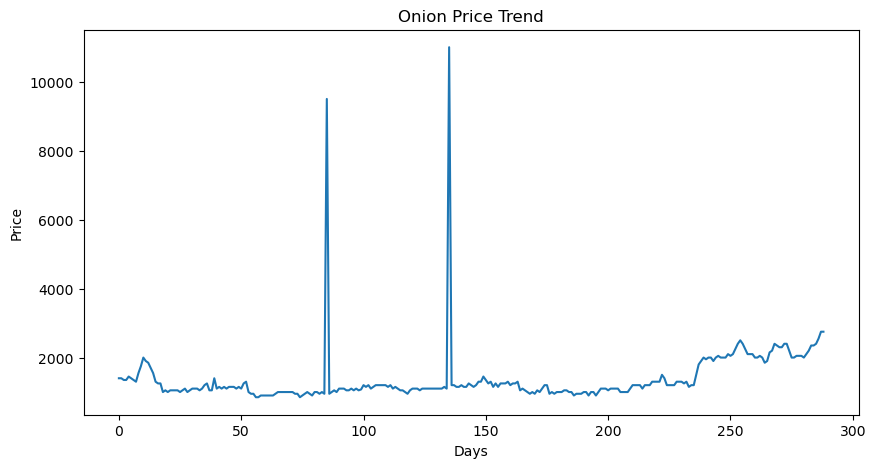

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['Modal Price'])
plt.title("Onion Price Trend")
plt.xlabel("Days")
plt.ylabel("Price")
plt.show()

In [29]:
def farmer_advice(lag1, lag2, lag3):
    
    price = predict_price(lag1, lag2, lag3)
    
    market, demand = recommend_market(price)
    
    print("Predicted Price:", price)
    print("Recommended Market:", market)
    print("Demand Level:", demand)

In [31]:
farmer_advice(1200,1300,1400)

Predicted Price: 1187.5261904761903
Recommended Market: Solapur APMC
Demand Level: Low
